### **Import Libraries**

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, roc_auc_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

### **Import Dataset**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving customer_churn_dataset.csv to customer_churn_dataset.csv


### **Read Dataset**

In [3]:
data = pd.read_csv("customer_churn_dataset.csv")
data

,Customer_ID,Age,Gender,Monthly_Spending,Subscription_Length,Support_Interactions,Churn
0,1,56,0,275,2,3,0
1,2,69,0,381,8,1,0
2,3,46,1,219,5,2,0
3,4,32,1,58,2,2,0
4,5,60,1,89,4,4,0
...,...,...,...,...,...,...,...
995,996,25,1,474,2,1,1
996,997,66,0,439,6,3,0
997,998,52,0,74,2,1,0
998,999,69,0,190,2,4,0


# **Exploratory Data Analysis (EDA)**

### **Dataset Information**

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Customer_ID           1000 non-null   int64
 1   Age                   1000 non-null   int64
 2   Gender                1000 non-null   int64
 3   Monthly_Spending      1000 non-null   int64
 4   Subscription_Length   1000 non-null   int64
 5   Support_Interactions  1000 non-null   int64
 6   Churn                 1000 non-null   int64
dtypes: int64(7)
memory usage: 54.8 KB


### **Descriptive Statistic**

In [5]:
data.describe()

,Customer_ID,Age,Gender,Monthly_Spending,Subscription_Length,Support_Interactions,Churn
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,44.385000,0.476000,275.791000,4.973000,1.959000,0.242000
std,288.819436,15.321669,0.499674,131.061193,2.555152,1.435053,0.428509
min,1.000000,18.000000,0.000000,50.000000,1.000000,0.000000,0.000000
25%,250.750000,31.750000,0.000000,166.000000,3.000000,1.000000,0.000000
50%,500.500000,45.000000,0.000000,278.000000,5.000000,2.000000,0.000000
75%,750.250000,57.000000,1.000000,387.250000,7.000000,3.000000,0.000000
max,1000.000000,70.000000,1.000000,500.000000,9.000000,4.000000,1.000000


### **Visualisasi Distribusi Churn**

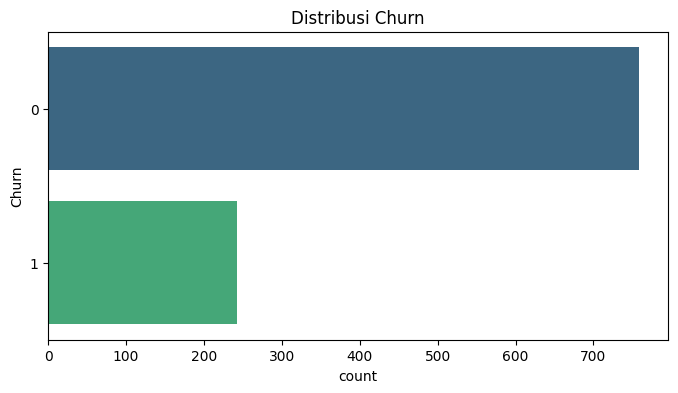

In [44]:
plt.figure(figsize=(8, 4))
sns.countplot(y='Churn', data=data, palette='viridis', hue='Churn', legend=False)
plt.title('Distribusi Churn')
plt.show()

#**Data Preprocessing**

## **Basic Pre Processing**

### **Drop Unused Column**

In [6]:
if 'Customer_ID' in data.columns:
    data = data.drop(columns="Customer_ID")

### **Checking Missing Value**

In [7]:
data.isnull().sum()

,0
Age,0
Gender,0
Monthly_Spending,0
Subscription_Length,0
Support_Interactions,0
Churn,0


## **Advanced Pre Processing**

### **Spliting Data Into Feature and Target Variable**

In [8]:
X = data.drop(columns="Churn")
y = data["Churn"]

### **Display Feature Data**

In [9]:
X

,Age,Gender,Monthly_Spending,Subscription_Length,Support_Interactions
0,56,0,275,2,3
1,69,0,381,8,1
2,46,1,219,5,2
3,32,1,58,2,2
4,60,1,89,4,4
...,...,...,...,...,...
995,25,1,474,2,1
996,66,0,439,6,3
997,52,0,74,2,1
998,69,0,190,2,4


### **Display Target Data**

In [10]:
y

,Churn
0,0
1,0
2,0
3,0
4,0
...,...
995,1
996,0
997,0
998,0


# **Decision Tree**

## **Advanced Pre Processing**

### **Splitting Data Into 80% Training and 20% Test Sets**

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### **Oversampling Using SMOTE**

In [12]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

## **Model Training**

### **Training the Model**

In [13]:
model_dt = DecisionTreeClassifier(random_state=42, max_depth=4)
model_dt.fit(X_train_smote, y_train_smote)

DecisionTreeClassifier(max_depth=4, random_state=42)

## **Model Evaluation**

### **Confusion Matrix**

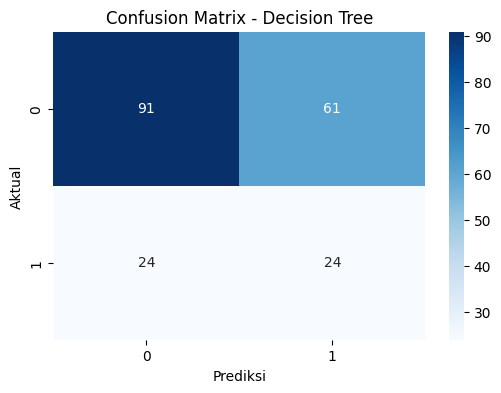

In [14]:
y_pred_dt = model_dt.predict(X_test)
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

### **Classification Report**

In [15]:
y_pred_dt = model_dt.predict(X_test)
cr_dt = classification_report(y_test, y_pred_dt)

print("\nClassification Report:")
print(cr_dt)


Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.60      0.68       152
           1       0.28      0.50      0.36        48

    accuracy                           0.57       200
   macro avg       0.54      0.55      0.52       200
weighted avg       0.67      0.57      0.60       200



### **Evaluate Model**

In [16]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, model_dt.predict_proba(X_test)[:, 1])

print("\nModel Evaluation:")
print(f"Decision Tree Accuracy: {accuracy_dt:.2f}")
print(f"Decision Tree Precision: {precision_dt:.2f}")
print(f"Decision Tree Recall: {recall_dt:.2f}")
print(f"Decision Tree F1-Score: {f1_dt:.2f}")
print(f"Decision Tree ROC-AUC Score: {roc_auc_dt:.2f}")


Model Evaluation:
Decision Tree Accuracy: 0.57
Decision Tree Precision: 0.28
Decision Tree Recall: 0.50
Decision Tree F1-Score: 0.36
Decision Tree ROC-AUC Score: 0.56


## **Cross-Validation Accuracy (5-fold)**

In [17]:
cv_scores_dt = cross_val_score(model_dt, X, y, cv=5)
cv_dt_mean = cv_scores_dt.mean()
print(f"\nAkurasi Cross-Validation (5-fold): {cv_scores_dt.mean():.2f} (+/- {cv_scores_dt.std():.2f})")


Akurasi Cross-Validation (5-fold): 0.74 (+/- 0.02)


## **Decision Tree Visualization**

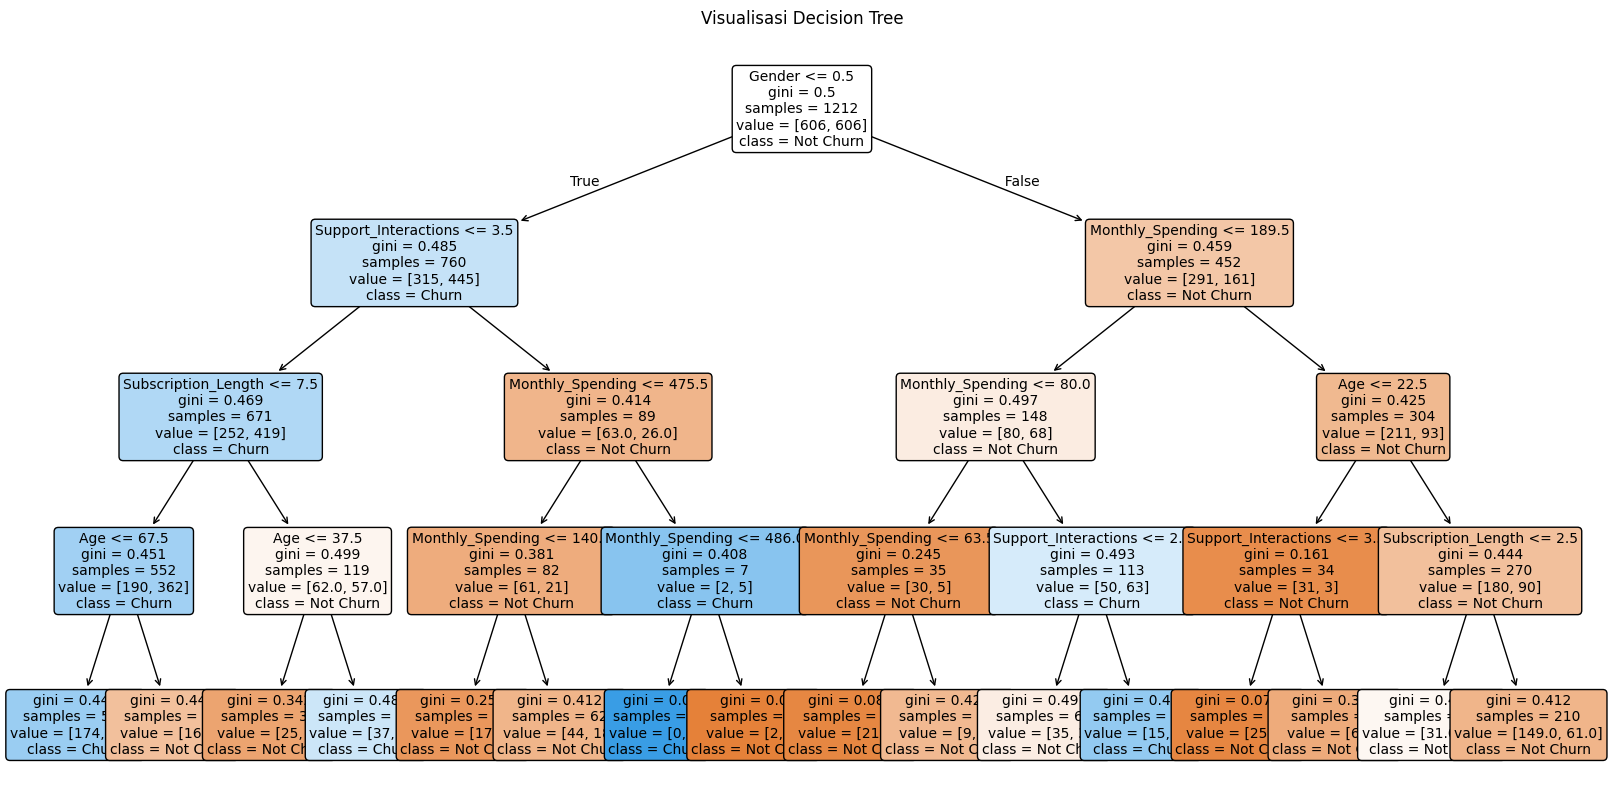

In [18]:
plt.figure(figsize=(20,10))
plot_tree(model_dt, feature_names=X.columns, class_names=['Not Churn', 'Churn'],
          filled=True, rounded=True, fontsize=10)
plt.title('Visualisasi Decision Tree')
plt.show()

# **K-NEAREST NEIGHBORS (KNN)**

## **Advanced Pre Processing**

### **Data Standarization**

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled_all = scaler.fit_transform(X)

### **Handling Imbalaced Data Using SMOTE**

In [20]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

## **Model Training**

### **Training the Model**

In [21]:
model_knn = KNeighborsClassifier(n_neighbors=3)
model_knn.fit(X_train_smote, y_train_smote)

KNeighborsClassifier(n_neighbors=3)

## **Model Evaluation**

### **Confusion Matrix**

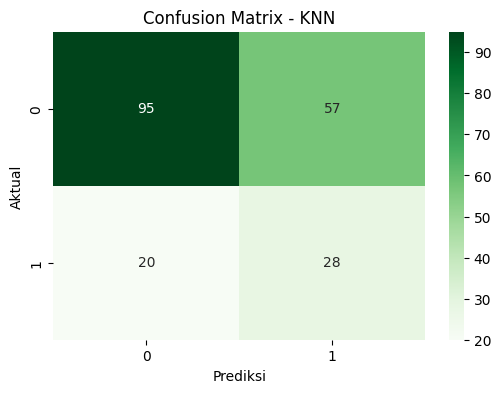

In [22]:
y_pred_knn = model_knn.predict(X_test_scaled)
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - KNN')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

### **Classification Report**

In [23]:
cr_knn = classification_report(y_test, y_pred_knn)

print("\nClassification Report:")
print(cr_knn)


Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.62      0.71       152
           1       0.33      0.58      0.42        48

    accuracy                           0.61       200
   macro avg       0.58      0.60      0.57       200
weighted avg       0.71      0.61      0.64       200



### **Evaluate Model**

In [24]:
accuracy_knn = model_knn.score(X_test_scaled, y_test)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
roc_auc_knn = roc_auc_score(y_test, model_knn.predict_proba(X_test_scaled)[:, 1])

print("\nModel Evaluation:")
print(f"K-Nearest Neighbors Accuracy: {accuracy_knn:.2f}")
print(f"K-Nearest Neighbors Precision: {precision_knn:.2f}")
print(f"K-Nearest Neighbors Recall: {recall_knn:.2f}")
print(f"K-Nearest Neighbors F1-Score: {f1_knn:.2f}")
print(f"K-Nearest Neighbors ROC-AUC Score: {roc_auc_knn:.2f}")


Model Evaluation:
K-Nearest Neighbors Accuracy: 0.61
K-Nearest Neighbors Precision: 0.33
K-Nearest Neighbors Recall: 0.58
K-Nearest Neighbors F1-Score: 0.42
K-Nearest Neighbors ROC-AUC Score: 0.61


## **Cross-Validation Accuracy (5-fold)**

In [25]:
cv_scores_knn = cross_val_score(model_knn, X_scaled_all, y, cv=5)
cv_knn_mean = cv_scores_knn.mean()
print(f"\nAkurasi Cross-Validation (5-fold): {cv_scores_knn.mean():.2f} (+/- {cv_scores_knn.std():.2f})")


Akurasi Cross-Validation (5-fold): 0.68 (+/- 0.02)


## **KNN Visualization using PCA**

In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_all)

pca_df = pd.DataFrame(data = X_pca, columns = ['principal_component_1', 'principal_component_2'])
pca_df['Churn'] = y.values

display(pca_df.head())

,principal_component_1,principal_component_2,Churn
0,-0.859206,-0.931245,0
1,-2.124011,0.493397,0
2,0.792033,0.139791,0
3,2.094259,-1.055685,0
4,0.859433,0.073302,0


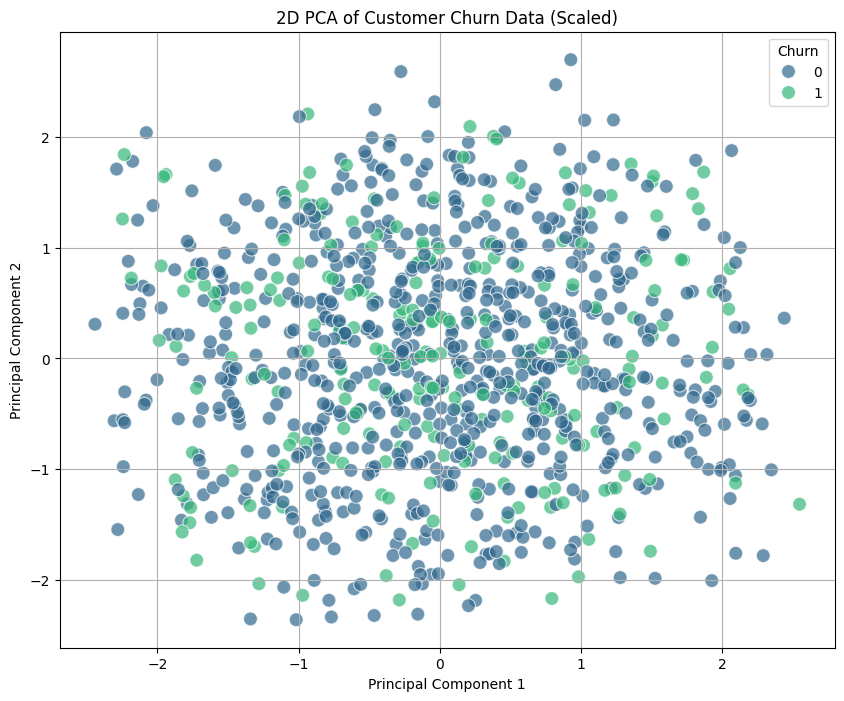

In [27]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='principal_component_1',
    y='principal_component_2',
    hue='Churn',
    data=pca_df,
    palette='viridis',
    s=100,
    alpha=0.7
)
plt.title('2D PCA of Customer Churn Data (Scaled)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

# **LOGISTIC REGRESSION**

## **Advanced Pre Processing**


### **Splitting Data Into 80% Training and 20% Test Sets**

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### **Data Standarization**

In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled_all = scaler.fit_transform(X)

### **Handling Imbalaced Data Using SMOTE**

In [30]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

## **Model Training**

### **Training the Model**

In [31]:
model_lr = LogisticRegression(random_state=42)
model_lr.fit(X_train_smote, y_train_smote)

LogisticRegression(random_state=42)

## **Model Evaluation**

### **Confusion Matrix**

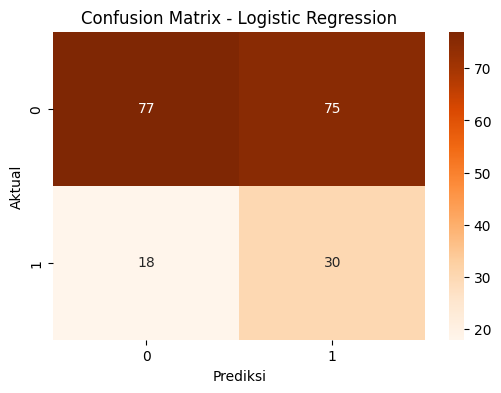

In [32]:
y_pred_lr = model_lr.predict(X_test_scaled)
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

### **Classification Report**

In [33]:
cr_lr = classification_report(y_test, y_pred_lr)

print("\nClassification Report:")
print(cr_lr)


Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.51      0.62       152
           1       0.29      0.62      0.39        48

    accuracy                           0.54       200
   macro avg       0.55      0.57      0.51       200
weighted avg       0.68      0.54      0.57       200



### **Evaluate Model**

In [34]:
accuracy_lr = model_lr.score(X_test_scaled, y_test)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, model_lr.predict_proba(X_test_scaled)[:, 1])

print("\nModel Evaluation:")
print(f"Logistic Regression Accuracy: {accuracy_lr:.2f}")
print(f"Logistic Regression Precision: {precision_lr:.2f}")
print(f"Logistic Regression Recall: {recall_lr:.2f}")
print(f"Logistic Regression F1-Score: {f1_lr:.2f}")
print(f"Logistic Regression ROC-AUC Score: {roc_auc_lr:.2f}")


Model Evaluation:
Logistic Regression Accuracy: 0.54
Logistic Regression Precision: 0.29
Logistic Regression Recall: 0.62
Logistic Regression F1-Score: 0.39
Logistic Regression ROC-AUC Score: 0.54


## **Cross-Validation Accuracy (5-fold)**

In [35]:
cv_scores_lr = cross_val_score(model_lr, X_scaled_all, y, cv=5)
cv_lr_mean = cv_scores_lr.mean()
print(f"\nAkurasi Cross-Validation (5-fold): {cv_scores_lr.mean():.2f} (+/- {cv_scores_lr.std():.2f})")


Akurasi Cross-Validation (5-fold): 0.76 (+/- 0.00)


# **Model Comparison**

In [36]:
comparison_df = pd.DataFrame({
    'Model': ['Decision Tree', 'K-Nearest Neighbors', 'Logistic Regression'],
    'Accuracy': [accuracy_dt, accuracy_knn, accuracy_lr],
    'Precision': [precision_dt, precision_knn, precision_lr],
    'Recall': [recall_dt, recall_knn, recall_lr],
    'F1-Score': [f1_dt, f1_knn, f1_lr],
    'ROC-AUC': [roc_auc_dt, roc_auc_knn, roc_auc_lr],
    'Cross-Validation Accuracy': [cv_dt_mean, cv_knn_mean, cv_lr_mean]
})

display(comparison_df.round(2))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Cross-Validation Accuracy
0,Decision Tree,0.57,0.28,0.50,0.36,0.56,0.74
1,K-Nearest Neighbors,0.62,0.33,0.58,0.42,0.61,0.68
2,Logistic Regression,0.54,0.29,0.62,0.39,0.54,0.76


### **Model Comparison Visualization (Accuracy)**

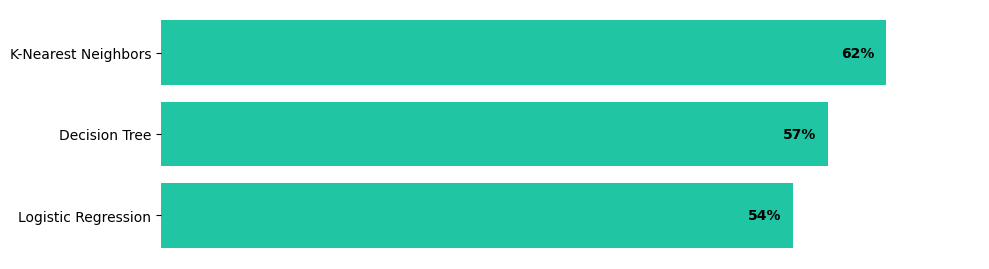

In [37]:
models = ['K-Nearest Neighbors', 'Decision Tree', 'Logistic Regression']
accuracy = [62, 57, 54]

plt.figure(figsize=(10, 2.8))

bars = plt.barh(models, accuracy, color='#20C5A3')

for bar in bars:
    width = bar.get_width()
    plt.text(width - 1,
             bar.get_y() + bar.get_height()/2,
             f'{width:.0f}%',
             va='center',
             ha='right',
             color='black',
             fontweight='bold')

plt.xlim(0, 70)
plt.gca().invert_yaxis()

plt.xticks([])
plt.box(False)

plt.tight_layout()
plt.show()

# **Combined Feature Importance**

### **Feature Importance - Decision Tree**

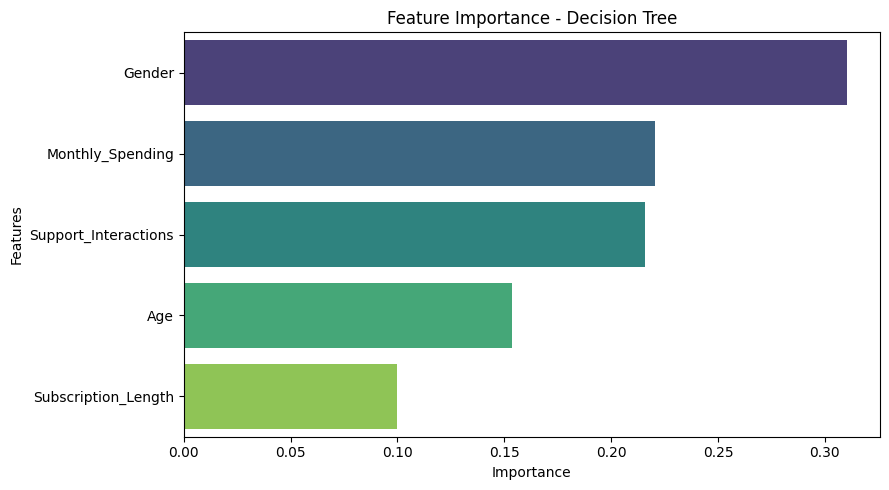

In [38]:
importance_dt = model_dt.feature_importances_
feat_imp_dt = pd.Series(importance_dt, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=feat_imp_dt.values, y=feat_imp_dt.index, palette='viridis', hue=feat_imp_dt.index, legend=False)
plt.title('Feature Importance - Decision Tree')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

### **Feature Importance - Logistic Regression**

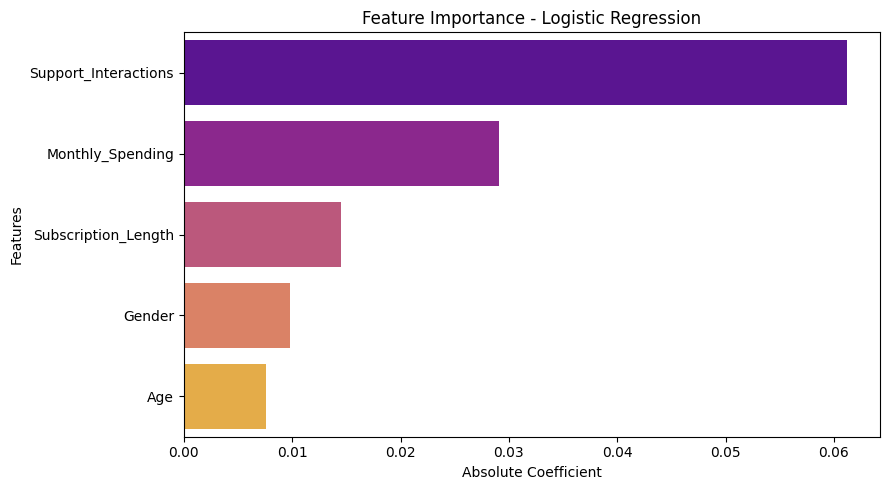

In [41]:
importance_lr = np.abs(model_lr.coef_[0])
feat_imp_lr = pd.Series(importance_lr, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=feat_imp_lr.values, y=feat_imp_lr.index, palette='plasma', hue=feat_imp_lr.index, legend=False)
plt.title('Feature Importance - Logistic Regression')
plt.xlabel('Absolute Coefficient')
plt.ylabel('Features')
plt.tight_layout()
plt.show()